In [1]:
import test_pipeline
import slice_util
import os
import numpy as np
import glob
import pandas as pd
import shutil
import trimesh
import importlib
#importlib.reload(puzzlefusion_plusplus.denoiser.dataset.dataset)
from puzzlefusion_plusplus.denoiser.dataset.dataset import build_test_dataloader
import test_pipeline
#importlib.reload(test_pipeline)
import importlib
import render_inference_result
#importlib.reload(slice_util)
#importlib.reload(render_inference_result)

#importlib.reload(puzzlefusion_plusplus.denoiser.dataset.dataset)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:

num_of_missing_slices = 5
from_index = 100
to_index = 210
tickness = 0.005
no_gap_between_slices = True
is_curvature = True
num_of_slilces = 10
data_id = f'{tickness:.3f}_{no_gap_between_slices}_{is_curvature}_{num_of_missing_slices}'

data_id = 'LS_10s_1000n_rot_y_un_e300'
data_type = 'brain_lightsheet'
#data_type = 'atlas_mouse_brain_50mm_mesh'
config_dir = '/home/jhahn/puzzlefusion-plusplus/config'
files_root =  '/home/jhahn/puzzlefusion-plusplus/web/files'
ckpt_path= f'/home/jhahn/puzzlefusion-plusplus/models/{data_id}/denoiser/training/epoch=789.ckpt'


cfg = test_pipeline.load_cfg(config_dir)


data_ids = [f'sliced_on_1_0_0_{tickness:.3f}_{no_gap_between_slices}_{num_of_missing_slices}_{from_index:03}_{is_curvature}_{to_index}_HIP']#['0408']
data_ids = ['sliced_on_0_0_1_0.0050_True_28_075_True_397_HIP_11']
#data_ids = ['sliced_on_1_0_0_0.003_True_5_100_True_209_HIP_12']
tiff_dir = '/data/jhahn/data/brain_lightsheet/slices/sliced_on_1_0_0'



In [3]:
'''
# get from real-world
tiff_dir = '/data/jhahn/data/brain_lightsheet/slices/sliced_on_1_0_0'
tiff_list = os.listdir(tiff_dir)
tiff_list.sort(key = lambda x: int(x.split(".")[0]))
tiff_list = tiff_list[from_index:to_index]

_num_of_slices = 0
for _i, f in enumerate(tiff_list):
    _id = int(f.split(".")[-2])
    if _i % (num_of_missing_slices+1) == 0:
        print(f, _i)
        _num_of_slices += 1
        shutil.copyfile(tiff_dir + "/" + f, tiff_dir_root + "/"+ f )    
        if _num_of_slices > num_of_slilces:
            break


#obj_dir_list_relative = obj_2_pcd.tiff_2_obj_parallel_test_mode(tiff_dir_root, None, tickness, num_of_missing_slices, 
#                                                      obj_dir_root, no_gap_between_slices = no_gap_between_slices, is_curvature = is_curvature)
    

import trimesh
import importlib
import test_pipeline
importlib.reload(test_pipeline)
import test_pipeline

obj_dir_list_relative = test_pipeline.tiff_2_obj(cfg, tiff_dir_root, tickness, obj_dir_root, pc_dir_root, num_of_missing_slices, no_gap_between_slices, is_curvature)
#obj_dir_list_relative = ['0.001_0.007']
#obj_dir_list_relative

obj_files = []
for _o in os.listdir(obj_dir_root + "/"+obj_dir_list_relative[0]):
    if not _o.endswith(".glb"):
        continue
    _glb = trimesh.load(obj_dir_root + "/"+obj_dir_list_relative[0]+"/"+_o)
    _new_obj_filename = render_output_dir+"/objs/"+_o.replace(".glb",".obj")
    _glb.export(_new_obj_filename)
    #print(_new_obj_filename)
    obj_files.append(_new_obj_filename)
slice_util.combine_obj_files(obj_files, render_output_dir+f"/gt_{data_id}.obj")


'''

'\n# get from real-world\ntiff_dir = \'/data/jhahn/data/brain_lightsheet/slices/sliced_on_1_0_0\'\ntiff_list = os.listdir(tiff_dir)\ntiff_list.sort(key = lambda x: int(x.split(".")[0]))\ntiff_list = tiff_list[from_index:to_index]\n\n_num_of_slices = 0\nfor _i, f in enumerate(tiff_list):\n    _id = int(f.split(".")[-2])\n    if _i % (num_of_missing_slices+1) == 0:\n        print(f, _i)\n        _num_of_slices += 1\n        shutil.copyfile(tiff_dir + "/" + f, tiff_dir_root + "/"+ f )    \n        if _num_of_slices > num_of_slilces:\n            break\n\n\n#obj_dir_list_relative = obj_2_pcd.tiff_2_obj_parallel_test_mode(tiff_dir_root, None, tickness, num_of_missing_slices, \n#                                                      obj_dir_root, no_gap_between_slices = no_gap_between_slices, is_curvature = is_curvature)\n    \n\nimport trimesh\nimport importlib\nimport test_pipeline\nimportlib.reload(test_pipeline)\nimport test_pipeline\n\nobj_dir_list_relative = test_pipeline.tiff_2_obj(cfg

In [4]:
import torch
import pytorch3d
from pytorch3d.io import IO
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    torch.cuda.set_device(device)
else:
    device = torch.device("cpu")



In [5]:
'''
init_pose_0 = np.load('/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/inference/0/init_pose.npy')
gt_0 = np.load('/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/inference/0/gt.npy')
gt_20parts = np.load('/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/inference/0/gt_20parts.npy')
part_valid = np.load('/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/inference/t_part_valids.npy')

noisy_trans_and_rots_0 = np.load('/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/inference/t_noisy_trans_and_rots.npy')

obj_3 = pytorch3d.io.load_obj('/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/objs/test/fractured/173.obj', device=device)[0].cpu().numpy()
predict_file_name = glob.glob(f'/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/inference/0/predict_20parts_*')[0]
predict_0 = np.load(predict_file_name)
'''

"\ninit_pose_0 = np.load('/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/inference/0/init_pose.npy')\ngt_0 = np.load('/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/inference/0/gt.npy')\ngt_20parts = np.load('/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/inference/0/gt_20parts.npy')\npart_valid = np.load('/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/inference/t_part_valids.npy')\n\nnoisy_trans_and_rots_0 = np.load('/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/inference/t_noisy_trans_and_rots.npy')\n\nobj_3 = pytorch3d.io.load_obj('/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_30_083_True_397_HIP_10/0/objs/test/fractured/173.obj', device=device)[0].cpu().numpy()\npredict_file_name = glob.glob(f'/home/jhahn/puzz

In [6]:
import puzzlefusion_plusplus.vqvae.dataset.dataset
importlib.reload(puzzlefusion_plusplus.vqvae.dataset.dataset)
from omegaconf import OmegaConf,open_dict
os.environ["CUDA_VISIBLE_DEVICES"]= "MIG-3cbcedd0-1078-5d94-b442-df9ffdfe02de" 
import puzzlefusion_plusplus.auto_aggl
importlib.reload(puzzlefusion_plusplus.auto_aggl)
import puzzlefusion_plusplus.denoiser.dataset.dataset
importlib.reload(puzzlefusion_plusplus.denoiser.dataset.dataset)
import puzzlefusion_plusplus.denoiser.evaluation.evaluator
importlib.reload(puzzlefusion_plusplus.denoiser.evaluation.evaluator)
import render_inference_result
importlib.reload(slice_util)
import utils.node_merge_utils
importlib.reload(utils.node_merge_utils)
import test_pipeline
importlib.reload(test_pipeline)
import verifier_utils
importlib.reload(verifier_utils)
importlib.reload(test_pipeline)
import torch
import puzzlefusion_plusplus.denoiser.evaluation.transform
importlib.reload(puzzlefusion_plusplus.denoiser.evaluation.transform)
import render_inference_result
importlib.reload(render_inference_result)
import test_pipeline
importlib.reload(test_pipeline)


shutil.rmtree(f'{files_root}/{data_ids[0]}', ignore_errors=True)

'''
tiff_dir_root, obj_dir_root, pc_dir_root, inference_dir_root, render_output_dir = test_pipeline.init_dir(files_root,data_ids)
print('tiff_dir_root',tiff_dir_root)
print('obj_dir_root',obj_dir_root)
print('pc_dir_root',pc_dir_root)
print('inference_dir_root',inference_dir_root)
print('render_output_dir',render_output_dir)
print('ckpt_path',ckpt_path)
'''
tiff_dir, inference_dir_root, obj_id_list , part_pcs_gt, original_vertices, part_valids, render_output_dir = None,None,None,None,None,None,None

cfg.data.file_ext = 'obj'

pre_inference_dir_root = None
pre_obj_dir_root = None
for iteration_num in range(1):
    print('----------------------------')
    print('iteration_num',iteration_num)


    tiff_dir_root, obj_dir_root, pc_dir_root, inference_dir_root, render_output_dir = test_pipeline.init_dir(files_root,data_ids,iteration_num)
    
    cfg.data.file_ext = 'obj'
    if iteration_num == 0:
        tiff_dir = f'/data/jhahn/data/{data_type}/slices/{"_".join(data_ids[0].split("_")[:5])}'
        test_pipeline.get_obj_from_testdataset(data_type, data_ids[0],tiff_dir,tiff_dir_root,obj_dir_root,render_output_dir)
        test_pipeline.obj_2_pc(cfg, obj_dir_root, pc_dir_root, tiff_dir)
        original_obj_filename_list = []
        for f in os.listdir(f'{obj_dir_root}/test/fractured/'):
            original_obj_filename_list.append(f'{obj_dir_root}/test/fractured/'+"/"+f)
        original_obj_filename_list.sort(key = lambda x: int(x.split("/")[-1].split(".")[-2]))
    

    else:
        data_id = 0


        np.savez(
            os.path.join(pc_dir_root, f'{data_id:05}.npz'),
            data_id=data_id,
            part_valids=part_valids[0].astype(np.float32),
            num_parts=num_parts,
            mesh_file_path=mesh_file_path,
            graph=graph,
            category=category,
            part_pcs_gt=part_pcs_gt.astype(np.float32),
            part_pcs=pts[0].astype(np.float32),
            ref_part=ref_part,
            gt=gt.astype(np.float32),
            init_pose=init_pose.astype(np.float32),
            part_scale=part_scale.astype(np.float32),

        )       





        

        os.makedirs(f'{obj_dir_root}/test/fractured/', exist_ok=True)
        for part_index, pcd_filename in enumerate(original_obj_filename_list):
        #for part_index in range(pts.shape[1]):
            part_id = int(pcd_filename.split("/")[-1].split(".")[-2])
            new_pcd_filename = f'{obj_dir_root}/test/fractured/{str(part_id).zfill(3)}.obj'
            if part_valids[0,part_index] == 1:

                if part_index == min_dist_indices[0][0].item():
                    slice_util.combine_obj_files(to_be_combined_files, new_pcd_filename)
                else:
                #point_cloud = trimesh.PointCloud(vertices=np.array(part_pcs_gt[part_index,:,:]))
                
                    shutil.copyfile(original_obj_filename_list[part_index], new_pcd_filename )

                
                #print(pcd_filename)
                #point_cloud.export(file_obj=pcd_filename)
    with open(obj_dir_root+"/tiff.txt", 'r', encoding='utf-8') as file:
        tiff_dir = file.readline().strip()
    pre_inference_dir_root = inference_dir_root
    pre_obj_dir_root = obj_dir_root
    inference_result_dir = test_pipeline.inference(cfg, pc_dir_root, ckpt_path, inference_dir_root)
    print(inference_result_dir)
    original_vertices, obj_id_list =render_inference_result.get_vertices(inference_dir_root, obj_dir_root)

    #vertices_gt, obj_id_list = render_inference_result.get_vertices(inference_dir_root, obj_dir_root, device=test_pipeline.device)
    data_dict = np.load(os.path.join(pc_dir_root, '00000.npz'))
    data_id = data_dict['data_id']
    part_valids = data_dict['part_valids']
    num_parts = data_dict['num_parts']
    mesh_file_path = data_dict['mesh_file_path']
    graph = data_dict['graph']
    category = data_dict['category']
    part_pcs_gt = data_dict['part_pcs_gt']
    ref_part = data_dict['ref_part']


    test_pipeline.render(tiff_dir, inference_dir_root, obj_id_list , part_pcs_gt, original_vertices, part_valids, render_output_dir)
    if True:
        break
    gt = np.load(f'{inference_result_dir}/0/gt.npy')
    gt_20parts = np.load(f'{inference_result_dir}/0/gt_20parts.npy')
    
    init_pose = np.load(f'{inference_result_dir}/0/init_pose.npy')
    part_scale = np.load(f'{inference_result_dir}/0/part_scale.npy')

    pts = np.load(inference_result_dir+"/t_pts.npy")
    expanded_part_scale = np.load(inference_result_dir+"/t_expanded_part_scale.npy")
    part_valids = np.load(inference_result_dir+"/t_part_valids.npy")
    noisy_trans_and_rots = np.load(inference_result_dir+"/t_noisy_trans_and_rots.npy")
    
    predict_file_name = glob.glob(f'{inference_result_dir}/0/predict_20parts*')[0]
    predict_0 = np.load(predict_file_name)

    gt = verifier_utils.combine_gt_pred(gt_20parts, predict_0, part_valids).astype(np.float32)

    part_distances = verifier_utils.calculate_part_pair_distances_gpu(torch.from_numpy(pts), torch.from_numpy(part_valids))
    min_dist, min_dist_indices = verifier_utils.find_min_non_zero_distance_index(part_distances)
    print(min_dist, min_dist_indices)

    part_1 = pts[0,min_dist_indices[0][0],:,:]
    part_2 = pts[0,min_dist_indices[0][1],:,:]
    part_merged = verifier_utils.merge_two_pcd_by_2d(part_1, part_2)
    pts[0,min_dist_indices[0][0].item(),:,:] = part_merged



    part_1 = part_pcs_gt[min_dist_indices[0][0],:,:]
    part_2 = part_pcs_gt[min_dist_indices[0][1],:,:]
    part_merged = verifier_utils.merge_two_pcd(part_1, part_2, num_of_points = 1000)
    part_pcs_gt[min_dist_indices[0][0].item(),:,:] = part_merged
   

    part_valids[0,min_dist_indices[0][1].item()] = 0



    to_be_combined_files = [original_obj_filename_list[min_dist_indices[0][0].item()],original_obj_filename_list[min_dist_indices[0][1].item()]]

----------------------------
iteration_num 0
/data/jhahn/data/shape_dataset/data/brain_lightsheet/sliced_on_0_0_1_0.0050_True_28_075_True_397_HIP_11/fractured_0
combining 11 files


dataset:  /home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_28_075_True_397_HIP_11/0/objs/test.txt
1 ['test']
mesh_dir /home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_28_075_True_397_HIP_11/0/objs/test
_gen_pc_data /home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_28_075_True_397_HIP_11/0/pc


Processing test data: 100%|██████████| 1/1 [00:00<00:00,  1.10it/s]


{'hydra': {'output_subdir': None, 'run': {'dir': '.'}}, 'defaults': ['_self_', 'denoiser/data', 'denoiser/model', 'denoiser/encoder', 'verifier/model', 'ae/model', 'ae/vq_vae', {'override hydra/hydra_logging': 'disabled'}, {'override hydra/job_logging': 'disabled'}], 'denoiser': {'ckpt_path': '/home/jhahn/puzzlefusion-plusplus/models/LS_10s_1000n_rot_y_un_e300/denoiser/training/epoch=789.ckpt', 'data': {'val_batch_size': 1, 'matching_data_path': './data/matching_data/', 'batch_size': 64, 'num_workers': 64, 'data_fn': 'brain_lightsheet.{}.txt', 'data_dir': '/data/jhahn/data/shape_dataset/pc_data/brain_lightsheet/train/', 'data_val_dir': '/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_28_075_True_397_HIP_11/0/pc', 'mesh_data_dir': '/data/jhahn/data/shape_dataset/data', 'rot_range': -1, 'overfit': -1, 'min_num_part': 2, 'max_num_part': 20}, 'ae': {'ae_name': {'_target_': 'puzzlefusion_plusplus.denoiser.model.modules.encoder.VQVAE'}, 'n_embeddings': 1024, 'embeddin

100%|██████████| 1/1 [00:00<00:00, 379.51it/s]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 4g.40gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-3cbcedd0-1078-5d94-b442-df9ffdfe02de]


Testing: |          | 0/? [00:00<?, ?it/s]

save_dir /home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_28_075_True_397_HIP_11/0/inference
_save_inference_data /home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_28_075_True_397_HIP_11/0/inference/0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      eval/part_acc                 1.0
       eval/rmse_r          15.001773834228516
       eval/rmse_t          0.01328441221266985
      eval/shape_cd        0.0007882168283686042
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
test done [{'eval/part_acc': 1.0, 'eval/rmse_t': 0.01328441221266985, 'eval/rmse_r': 15.001773834228516, 'eval/shape_cd': 0.0007882168283686042}]
/home/jhahn/puzzl

100%|██████████| 11/11 [00:00<00:00, 34.39it/s]


TypeError: render() missing 1 required positional argument: 'render_output_dir'

In [ ]:
tiff_dir

In [ ]:
expanded_part_scale = np.load(inference_result_dir+"/t_expanded_part_scale.npy")
expanded_part_scale[0,18,:,:]

pts = np.load(inference_result_dir+"/t_pts.npy")
print(pts.shape)
pts = np.squeeze(pts)


scale = np.max(np.abs(pts), axis=(1,2), keepdims=True)
scale[scale == 0] = 1

#expanded_part_scale = scale.unsqueeze(-1).expand(-1, -1, 1000, -1)
#pts = pts * expanded_part_scale
for i in range(20):
    #print(np.max(pts[i,:,:], axis=0), np.min(pts[i,:,:], axis=0))
    #print(scale[i,:,:])
    print(expanded_part_scale[0,i,0,:].item())


In [ ]:
for riwon in range(10):
    r = 100 + riwon 
    print(r)

100
101
102
103
104
105
106
107
108
109


gen snapshot images:   0%|          | 0/11 [00:00<?, ?it/s]

adustment:   0%|          | 0/4 [00:00<?, ?it/s]

19 / ADJUST / ['327', '299', '271', '243']


adustment:  25%|██▌       | 1/4 [00:03<00:11,  3.77s/it]

20 / ADJUST / ['327', '299', '271', '243']


adustment:  50%|█████     | 2/4 [00:07<00:07,  3.76s/it]

21 / ADJUST / ['327', '299', '271', '243']


adustment:  75%|███████▌  | 3/4 [00:11<00:03,  3.76s/it]

22 / ADJUST / ['327', '299', '271', '243']


gen videos:  75%|███████▌  | 3/4 [00:00<00:00,  4.66it/s]IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 800) to (1008, 800) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x1002c240] Stream #0: not enough frames to estimate rate; consider increasing probesize
gen videos: 100%|██████████| 4/4 [00:01<00:00,  3.29it/s]


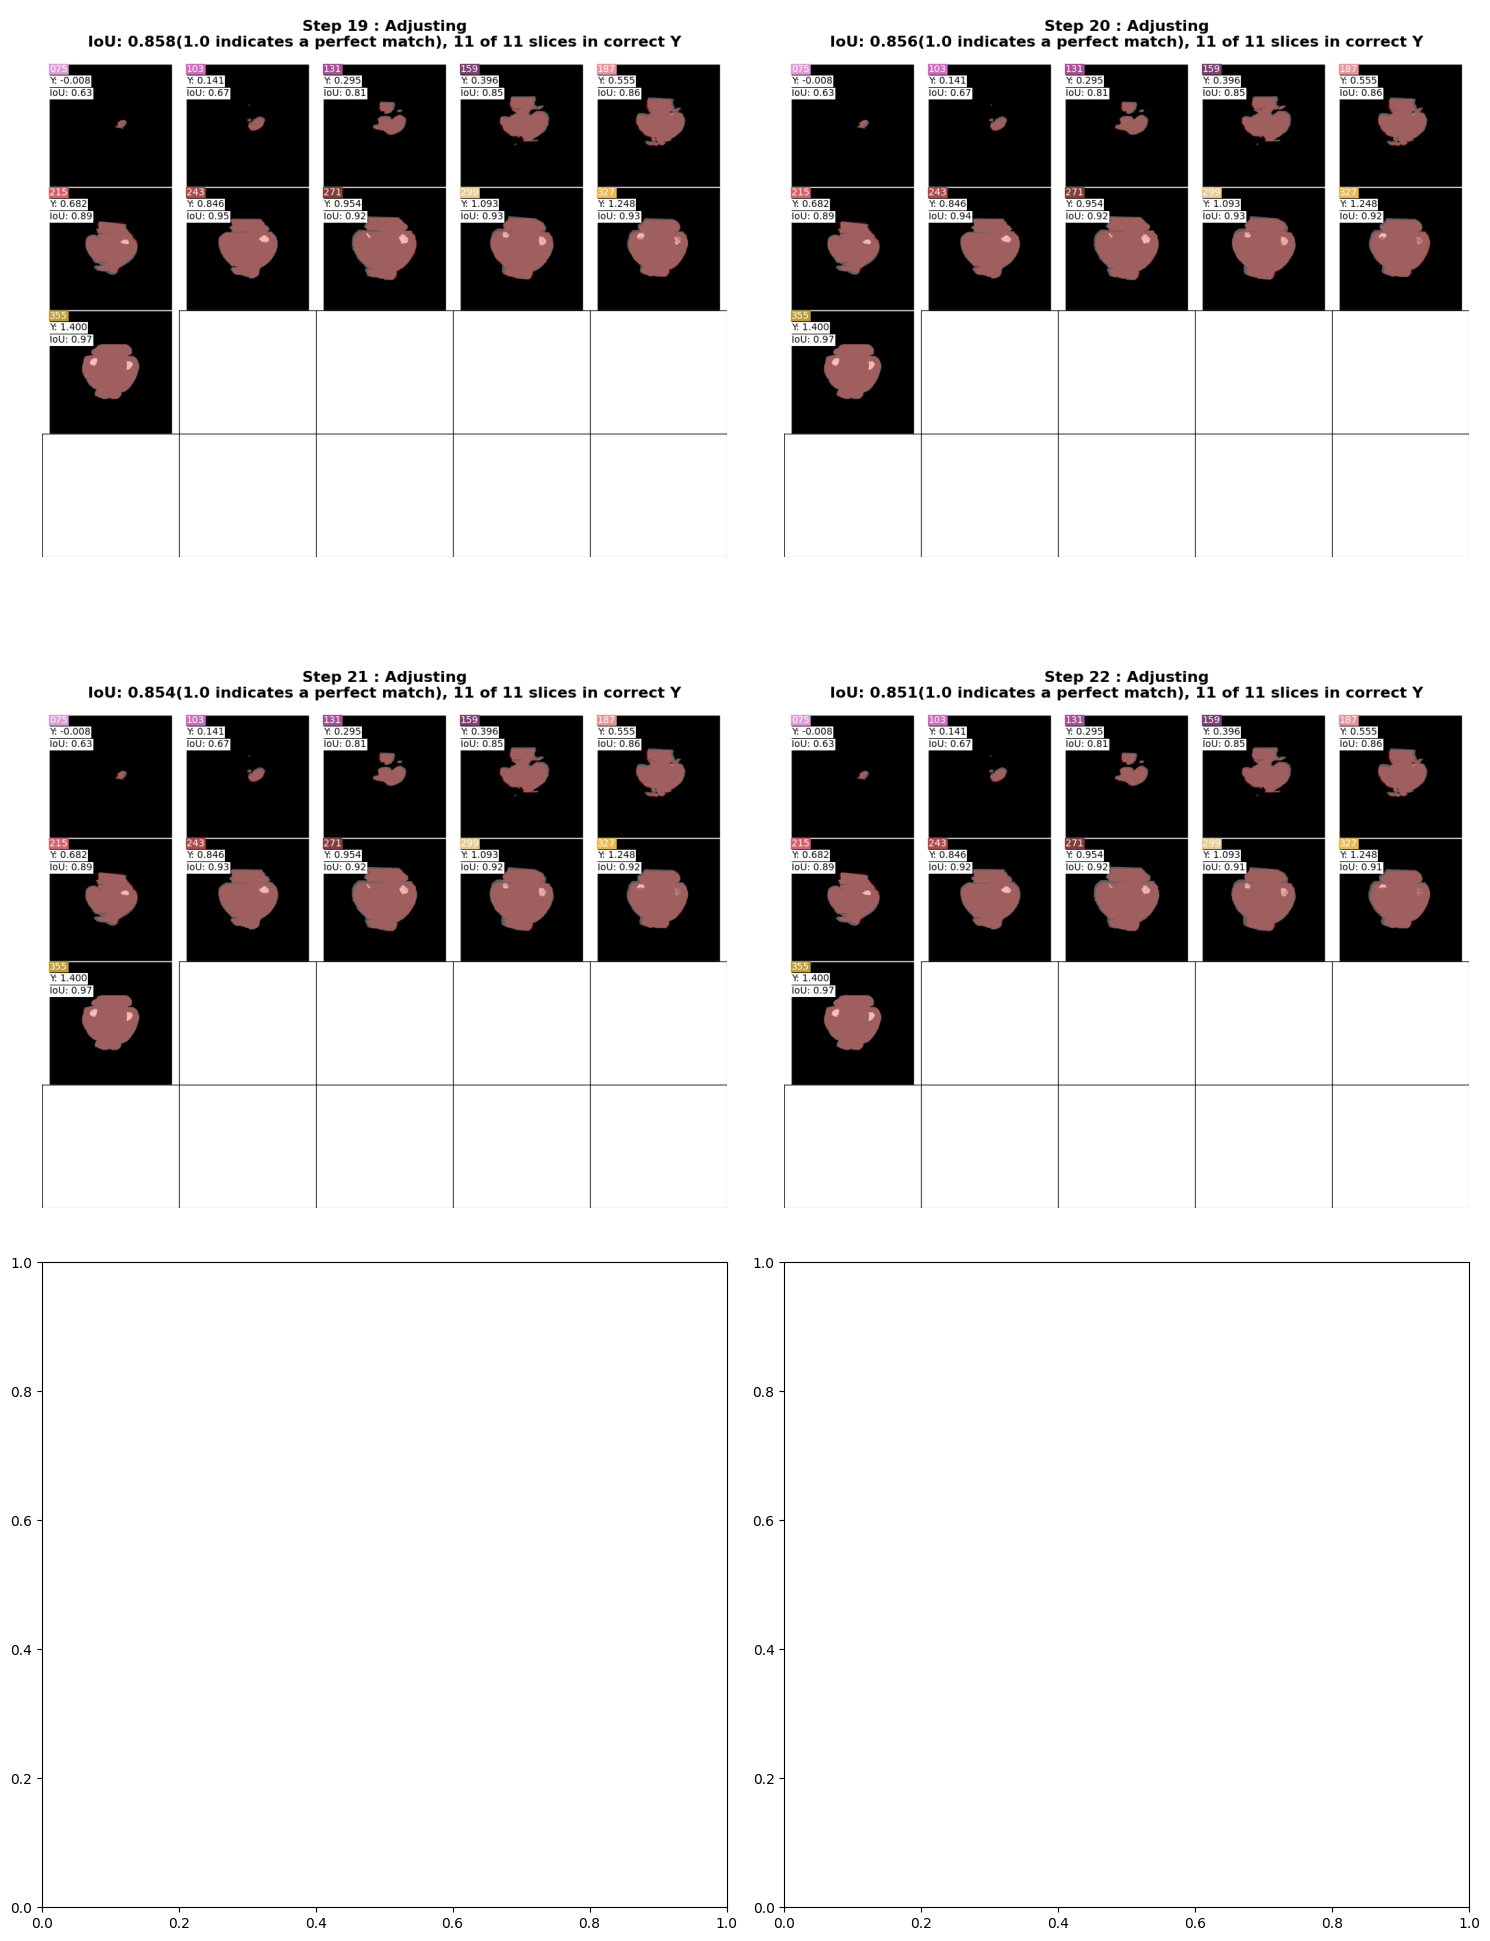

In [9]:
import puzzlefusion_plusplus.vqvae.dataset.dataset
importlib.reload(puzzlefusion_plusplus.vqvae.dataset.dataset)
from omegaconf import OmegaConf,open_dict
os.environ["CUDA_VISIBLE_DEVICES"]= "MIG-3cbcedd0-1078-5d94-b442-df9ffdfe02de" 
import puzzlefusion_plusplus.auto_aggl
importlib.reload(puzzlefusion_plusplus.auto_aggl)
import puzzlefusion_plusplus.denoiser.dataset.dataset
importlib.reload(puzzlefusion_plusplus.denoiser.dataset.dataset)
import puzzlefusion_plusplus.denoiser.evaluation.evaluator
importlib.reload(puzzlefusion_plusplus.denoiser.evaluation.evaluator)
import render_inference_result
importlib.reload(slice_util)
import utils.node_merge_utils
importlib.reload(utils.node_merge_utils)
import test_pipeline
importlib.reload(test_pipeline)
import verifier_utils
importlib.reload(verifier_utils)
importlib.reload(test_pipeline)
import torch
import puzzlefusion_plusplus.denoiser.evaluation.transform
importlib.reload(puzzlefusion_plusplus.denoiser.evaluation.transform)
import render_inference_result
importlib.reload(render_inference_result)
import test_pipeline
importlib.reload(test_pipeline)
expanded_part_scale = np.load(inference_result_dir+"/t_expanded_part_scale.npy")

last_step_idx = test_pipeline.render(tiff_dir, inference_dir_root, obj_id_list , part_pcs_gt, original_vertices, expanded_part_scale, part_valids, render_output_dir)


import matplotlib.pyplot as plt
import matplotlib.image as mpimg


# 3. 서브플롯 생성 (1행 2열)
fig, axes = plt.subplots(3, 2, figsize=(15, 20)) # figsize로 전체 그림 크기 조절
ax_flat = axes.flatten()
for _idx, _step_id in enumerate(range(last_step_idx - 3,last_step_idx+1)):
        
    image_path1 = f'/home/jhahn/puzzlefusion-plusplus/web/files/sliced_on_0_0_1_0.0050_True_28_075_True_397_HIP_11/0/render/0/steps/{_step_id}_mask.png'  # 첫 번째 파일 경로
    _img = mpimg.imread(image_path1)
    ax_flat[_idx].imshow(_img)
    ax_flat[_idx].set_title("")
    ax_flat[_idx].axis('off') # 축 눈금 제거

# 6. 출력
plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import FileLink, display
folder_to_download = pc_dir_root.replace("/pc","") 
zip_file_name = test_pipeline.zip_and_download_folder(folder_to_download)
display(FileLink(zip_file_name))